In [1]:
from torch_harmonics.spherical_harmonics import SphericalHarmonics

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from torch_harmonics import plotting
import xarray
import torch
from torch import nn

In [3]:
f = xarray.load_dataset('/home/colin/hdd/workspace/datasets/test_dataset.nc')

In [4]:
f['rti'].shape
# Aspect is at 180 (61)

(3000, 61, 21, 107, 2)

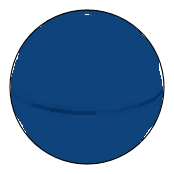

In [34]:
sample = f['rti'][0,:,:,0,0]
y = torch.tensor(sample.to_numpy()).view(1,61,21)#.repeat(1,2,1)
plotting.plot_spherical_fn(y.squeeze().numpy(), fig=plt.figure(figsize=(2,2)))

import matplotlib.animation as animation

fig = plt.figure(layout='constrained', figsize=(12, 8), dpi=72)

moviewriter = animation.writers['pillow'](fps=30)
moviewriter.setup(fig, 'radar_2.gif', dpi=72)

num_frames = 360
for frame in range(num_frames):
    # compute the rotation of the sphere
    lon = -num_frames - (360 / num_frames) * frame

    if frame % 10 == 0:
        print(f"frame={frame}")
    
        plotting.plot_spherical_fn(y.squeeze().numpy(), fig=fig, central_longitude=lon)

    plt.draw()
    moviewriter.grab_frame()

moviewriter.finish()

In [35]:
class SHT(nn.Module):
    def __init__(self, L=3, num_theta=61*1, num_phi=21):
        super().__init__()
        self.L = L
        self.w_lin = nn.Linear(num_theta*num_phi, L*(L+1)*2)
        self.sh = SphericalHarmonics(L, num_lat=num_theta, num_lon=num_phi)
        #self.mlp_out = nn.Linear(num_range*num_theta*num_phi, num_range*num_theta*num_phi)

    def forward(self, x):
        B = x.size(0)
        
        w = self.w_lin(x)
        w = w.view(-1, self.L, self.L+1, 2)
        
        y = self.sh(w).float()#.view(B, self.num_range)
        #y = self.mlp_out(y).view(B,self.sh.num_lat, self.sh.num_lon)
        return y.view(B, self.sh.num_lat, self.sh.num_lon), w.detach()

In [36]:
L = 150
sh_model = SHT(L).cuda()
optimizer = torch.optim.Adam(sh_model.parameters(), lr = 1e-4)

for iter in range(1000):
    y_pred, _ = sh_model(y.view(1,-1).cuda())
    loss = (y_pred - y.cuda()).pow(2).mean()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if iter % 10 == 0:
        print(f'iteration: {iter} loss: {loss.item()}')

iteration: 0 loss: 0.9036629796028137
iteration: 10 loss: 0.25379693508148193
iteration: 20 loss: 0.09077232331037521
iteration: 30 loss: 0.03570102900266647
iteration: 40 loss: 0.017220498993992805
iteration: 50 loss: 0.009081253781914711
iteration: 60 loss: 0.005416518077254295
iteration: 70 loss: 0.003484223270788789
iteration: 80 loss: 0.0023892559111118317
iteration: 90 loss: 0.0016850224928930402
iteration: 100 loss: 0.0012083849869668484
iteration: 110 loss: 0.0008728689863346517
iteration: 120 loss: 0.0006334166973829269
iteration: 130 loss: 0.0004602436674758792
iteration: 140 loss: 0.00033480580896139145
iteration: 150 loss: 0.00024381086404900998
iteration: 160 loss: 0.00017776931053958833
iteration: 170 loss: 0.00012985167268197984
iteration: 180 loss: 9.507390495855361e-05
iteration: 190 loss: 6.980464240768924e-05
iteration: 200 loss: 5.1413622713880613e-05
iteration: 210 loss: 3.799750629696064e-05
iteration: 220 loss: 2.8182068490423262e-05
iteration: 230 loss: 2.097717

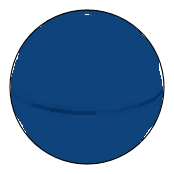

In [37]:
with torch.no_grad():
    pred, w = sh_model(y.view(1,-1).cuda())
    plotting.plot_spherical_fn(pred.cpu().squeeze().numpy(), fig=plt.figure(figsize=(2,2)))

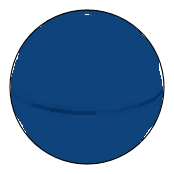

In [38]:
plotting.plot_spherical_fn(y.squeeze().numpy(), fig=plt.figure(figsize=(2,2)))

In [ ]:
sorted, idxs = torch.sort(torch.abs(w))

In [ ]:
print(idxs[0,-100:].numpy())
sorted[0,-100:].numpy().round(3)

In [ ]:
torch.sum(torch.abs(w) < 0.05)

In [ ]:
torch.mean(torch.abs(w))

In [ ]:
import matplotlib.animation as animation

fig = plt.figure(layout='constrained', figsize=(12, 8), dpi=72)

moviewriter = animation.writers['pillow'](fps=30)
moviewriter.setup(fig, 'pred_radar_2__l=100.gif', dpi=72)

num_frames = 360
for frame in range(num_frames):
    # compute the rotation of the sphere
    lon = -num_frames - (360 / num_frames) * frame

    if frame % 10 == 0:
        print(f"frame={frame}")
    
        plotting.plot_spherical_fn(pred.squeeze().numpy(), fig=fig, central_longitude=lon)

    plt.draw()
    moviewriter.grab_frame()

moviewriter.finish()

## Ground Truth
![SegmentLocal](radar.gif "segment")

## Prediction
![SegmentLocal](pred_radar.gif "segment")

## Ground Truth
![SegmentLocal](radar_2.gif "segment")

## Prediction
![SegmentLocal](pred_radar_2.gif "segment")